# Praktikum Pemrograman - Minggu 6

---
## 06A. Untung Rugi
### Description
Hadi sedang tertarik untuk belajar berinvestasi melalui jual-beli saham. Dia telah mengumpulkan data-data yang terkait dengan beberapa saham yang ingin ia beli, yaitu berupa nilai-nilai harga saham dan naik-turunnya harga saham-saham tersebut.

Harga saham berubah setiap pekan. Nilai harga saham pekan ini menentukan berapa keuntungan (atau kerugian) dari pemilik saham, berdasarkan nilai saham pada pekan sebelumnya. 
* Contoh untung: Pekan lalu Rp 1150, Pekan ini Rp 1300 $\rightarrow$ Untung Rp 150.
* Contoh rugi: Pekan lalu Rp 1400, Pekan ini Rp 1300 $\rightarrow$ Rugi Rp 100.

Tentukan berapakah nilai keuntungan dan kerugian terbesar yang didapatkan oleh pemilik saham tersebut dalam satu pekan!

### Input Format
Nilai $N$ menyatakan banyaknya pekan ($2 \le N \le 100000$). Diikuti $N$ nilai $A_1, A_2, \dots, A_N$ yang menyatakan harga saham pekan ke-1 s/d ke-$N$.

### Output Format
Dua bilangan $U$ dan $R$ dipisah spasi. $U$ adalah untung terbesar, $R$ adalah rugi terbesar.

### Sample Input
```
8
1 2 7 3 8 7 1 5
```
### Sample Output
```
5 6
```

### Thought Process (Pola Pikir)
Kita tidak perlu menyimpan seluruh data saham ke dalam *array*. Cukup proses secara berurutan (*stream processing*).
1. Baca harga pekan pertama dan simpan sebagai `prev`.
2. Lakukan perulangan sebanyak $N-1$ kali untuk membaca pekan-pekan berikutnya (`new`).
3. Hitung selisihnya: 
   * Jika naik (`new > prev`), hitung untung: `new - prev`. Bandingkan dengan `maxUntung`.
   * Jika turun (`new < prev`), hitung rugi: `prev - new`. Bandingkan dengan `maxRugi`.
4. _Update_ nilai `prev = new` untuk iterasi selanjutnya.

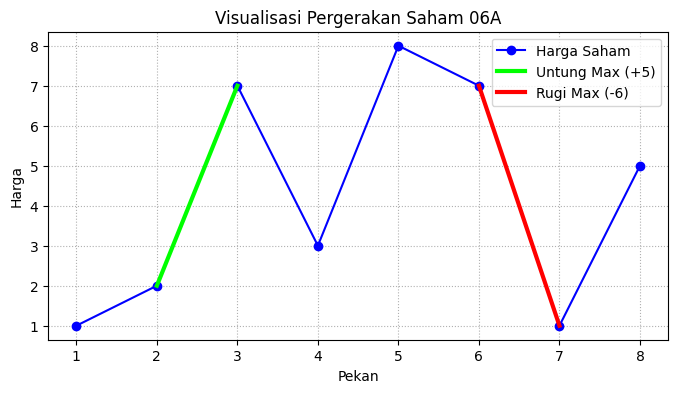

In [1]:
import matplotlib.pyplot as plt

def plot_saham(harga):
    pekan = list(range(1, len(harga) + 1))
    plt.figure(figsize=(8, 4))
    plt.plot(pekan, harga, marker='o', linestyle='-', color='b', label='Harga Saham')
    
    # Cari Max Untung & Max Rugi untuk di-highlight
    max_u, max_r = 0, 0
    idx_u, idx_r = 0, 0
    for i in range(1, len(harga)):
        diff = harga[i] - harga[i-1]
        if diff > max_u:
            max_u, idx_u = diff, i
        if diff < -max_r:
            max_r, idx_r = -diff, i
            
    # Highlight Untung (Hijau) & Rugi (Merah)
    if max_u > 0:
        plt.plot([pekan[idx_u-1], pekan[idx_u]], [harga[idx_u-1], harga[idx_u]], color='lime', lw=3, label=f'Untung Max (+{max_u})')
    if max_r > 0:
        plt.plot([pekan[idx_r-1], pekan[idx_r]], [harga[idx_r-1], harga[idx_r]], color='red', lw=3, label=f'Rugi Max (-{max_r})')

    plt.title("Visualisasi Pergerakan Saham 06A")
    plt.xlabel("Pekan")
    plt.ylabel("Harga")
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

plot_saham([1, 2, 7, 3, 8, 7, 1, 5])

In [2]:
%%writefile practicumWeek6a.c
# include <stdio.h>

int main() {
  int n;
  int prev, new_val;
  int maxUntung = 0, maxRugi = 0;
  
  scanf("%d", &n);
  scanf("%d", &prev);
  
  // Perbaikan loop: n-1 karena elemen pertama (prev) sudah dibaca
  for (int i = 0; i < n - 1; i++) {
    scanf("%d", &new_val);
    if (new_val >= prev) {
      if (maxUntung < (new_val - prev)) {
        maxUntung = new_val - prev;
      }
    } else {
      if (maxRugi < (prev - new_val)) {
        maxRugi = prev - new_val;
      }
    }
    prev = new_val;
  }
  
  printf("%d %d\n", maxUntung, maxRugi);
  return 0;
}

Writing practicumWeek6a.c


In [3]:
!gcc practicumWeek6a.c -o practicumWeek6a && echo 8 1 2 7 3 8 7 1 5 | practicumWeek6a.exe

5 6


---
## 06B. Kotak Angka
### Description
Buat program untuk membentuk kotak berukuran $M \times N$ yang berisi angka 0, 1, 2, ...., 9, 0, 1, 2, .... dan seterusnya.

### Input Format
Dua bilangan $M$ dan $N$ ($1 \le M, N \le 100$) yang dipisahkan oleh spasi.

### Output Format
Kotak angka seperti dijelaskan dalam deskripsi soal.

### Sample Input
```
3 4
```
### Sample Output
```
0 1 2 3
4 5 6 7
8 9 0 1
```

### Thought Process
Ini adalah manipulasi *nested loop* (perulangan bersarang) standar.
1. Loop luar `for (i = 0; i < baris; i++)` mengendalikan pencetakan ke bawah (baris per baris).
2. Loop dalam `for (j = 0; j < kolom; j++)` mengendalikan pencetakan ke kanan.
3. Kita gunakan satu variabel *counter* (misal `nilai = 0`). Setiap kali setelah diprint, `nilai` dinaikkan 1. Jika mencapai 10 (atau setelah mem-print angka 9), kembalikan `nilai` menjadi 0. Metode lain adalah memanfaatkan operasi modulus: `nilai = (nilai + 1) % 10`.

In [4]:
%%writefile practicumWeek6b.c
# include <stdio.h>

int main() {
  int baris, kolom, nilai = 0;
  scanf("%d %d", &baris, &kolom);
  
  for (int i = 0; i < baris; i++) {
    for (int j = 0; j < kolom; j++) {
      if (nilai == 9) {
        printf("%d ", nilai);
        nilai = 0;
      } else {
        printf("%d ", nilai);
        nilai++;
      }
    }
    printf("\n");
  }
  return 0;
}

Writing practicumWeek6b.c


In [5]:
!gcc practicumWeek6b.c -o practicumWeek6b && echo 3 4 | practicumWeek6b.exe

0 1 2 3 
4 5 6 7 
8 9 0 1 


---
## 06C. Naik Turun
### Description
Mengkombinasikan barisan ganjil dan genap secara selang-seling. Barisan ganjil ditulis menaik, sedangkan barisan genap ditulis menurun.
* Contoh Ganjil (Naik) 5 suku: 1, 3, 5, 7, 9
* Contoh Genap (Turun) 5 suku: 10, 8, 6, 4, 2
* Hasil Kombinasi ($N=5$): 1, 10, 3, 8, 5, 6, 7, 4, 9, 2

**Penting:** Dilarang menggunakan *array*.

### Input Format
Sebuah bilangan bulat $N$ ($1 \le N \le 100000$).

### Sample Input
```
5
```
### Sample Output
```
1 10 3 8 5 6 7 4 9 2
```

### Thought Process
Karena tidak boleh menggunakan *array*, kita harus bisa mencetaknya secara berurutan dari kiri ke kanan. 
1. Siapkan 2 variabel/pointer penunjuk keadaan: 
   * `ganjil` mulai dari 1 (bergerak $+2$)
   * `genap` mulai dari $2 \times N$ (bergerak $-2$)
2. Kita harus mencetak total $2 \times N$ angka.
3. Lakukan iterasi `for` sebanyak $2N$ kali.
   * Di indeks ganjil, cetak nilai `ganjil` lalu naikkan.
   * Di indeks genap, cetak nilai `genap` lalu turunkan.

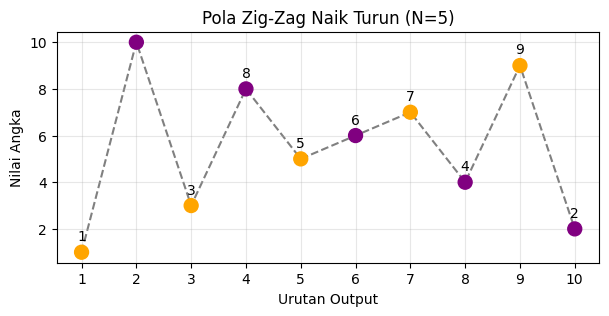

In [6]:
import matplotlib.pyplot as plt

def plot_zigzag(n):
    ganjil = 1
    genap = 2 * n
    seq = []
    colors = []
    for i in range(1, 2*n + 1):
        if i % 2 != 0:
            seq.append(ganjil)
            colors.append('orange')
            ganjil += 2
        else:
            seq.append(genap)
            colors.append('purple')
            genap -= 2
            
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, 2*n + 1), seq, color='gray', linestyle='--', zorder=1)
    plt.scatter(range(1, 2*n + 1), seq, c=colors, s=100, zorder=2)
    for i, txt in enumerate(seq):
        plt.annotate(txt, (i+1, seq[i]+0.5), ha='center')
        
    plt.title(f"Pola Zig-Zag Naik Turun (N={n})")
    plt.xlabel("Urutan Output")
    plt.ylabel("Nilai Angka")
    plt.xticks(range(1, 2*n + 1))
    plt.grid(True, alpha=0.3)
    plt.show()

plot_zigzag(5)

In [7]:
%%writefile practicumWeek6c.c
# include <stdio.h>

int main() {
  int n;
  int ganjil = 1;
  scanf("%d", &n);
  int genap = 2 * n;
  
  for (int i = 1; i <= 2 * n; i++) {
    if (i % 2 != 0) {
      printf("%d ", ganjil);
      ganjil += 2;
    } else {
      printf("%d ", genap);
      genap -= 2;
    }
  }
  printf("\n");
  return 0;
}

Writing practicumWeek6c.c


In [8]:
!gcc practicumWeek6c.c -o practicumWeek6c && echo 5 | practicumWeek6c.exe

1 10 3 8 5 6 7 4 9 2 
